# Regression tree complexity and held-out error

Compare predeclared tree settings on synthetic quadratic data with noise. Plot labels match actual settings. Report mean absolute error as MAE.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
rng=np.random.default_rng(42)
X=rng.random((200,1));y=4*(X[:,0]-0.5)**2+rng.normal(0,0.1,200)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)
models={'mean_baseline':DummyRegressor(),
        'max_depth=2':DecisionTreeRegressor(max_depth=2,random_state=42),
        'max_depth=3':DecisionTreeRegressor(max_depth=3,random_state=42),
        'unrestricted':DecisionTreeRegressor(random_state=42),
        'min_samples_leaf=10':DecisionTreeRegressor(min_samples_leaf=10,random_state=42)}
rows=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    rows.append({'model':name,'train_MAE':mean_absolute_error(y_train,model.predict(X_train)),
                 'test_MAE':mean_absolute_error(y_test,model.predict(X_test))})
display(pd.DataFrame(rows))


,model,train_MAE,test_MAE
0,mean_baseline,0.237585,0.254877
1,max_depth=2,0.125779,0.143558
2,max_depth=3,0.084394,0.114812
3,unrestricted,0.000000,0.137215
4,min_samples_leaf=10,0.084404,0.115213


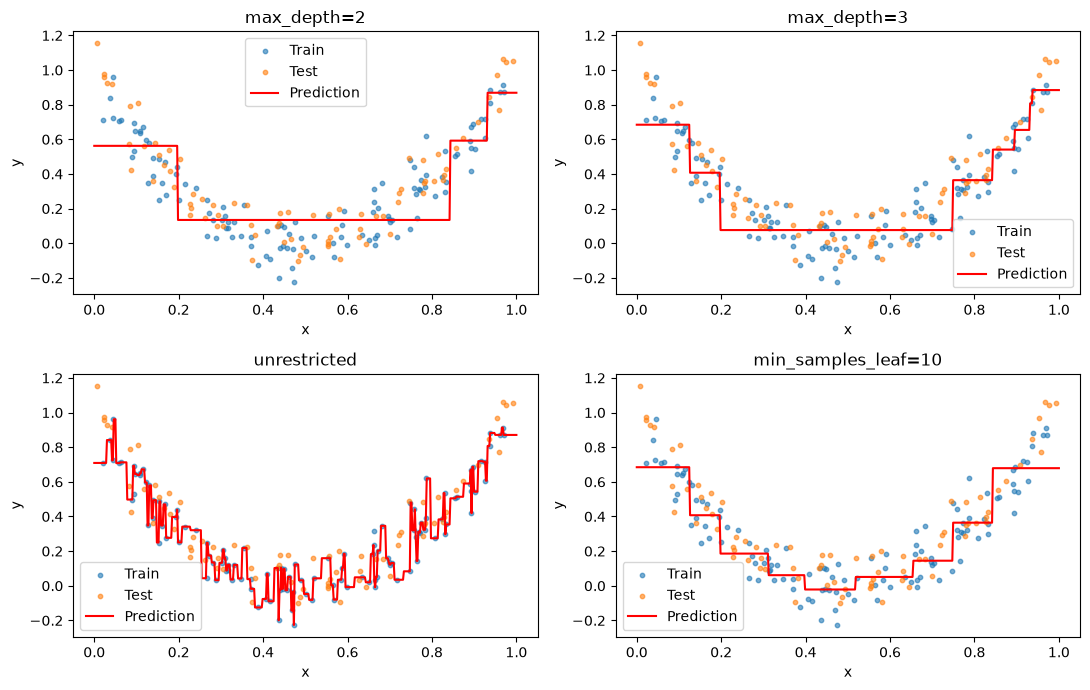

In [2]:
xx=np.linspace(0,1,500).reshape(-1,1)
fig,axes=plt.subplots(2,2,figsize=(11,7))
for ax,(name,model) in zip(axes.flat,[(n,m) for n,m in models.items() if n!='mean_baseline']):
    ax.scatter(X_train[:,0],y_train,s=10,label='Train',alpha=0.6)
    ax.scatter(X_test[:,0],y_test,s=10,label='Test',alpha=0.6)
    ax.plot(xx[:,0],model.predict(xx),color='red',label='Prediction')
    ax.set(title=name,xlabel='x',ylabel='y');ax.legend()
plt.tight_layout();plt.show()


The configurations are an illustrative comparison, not tuned using the test scores. An unrestricted tree can memorise training noise. The test comparison is specific to this synthetic generator and split. A stronger model-selection experiment would tune on training folds and evaluate the selected model once on a fresh holdout.
